# 1. Environment Setup & Data Ingestion
Initializing core libraries and fetching the raw 500k+ row transactional dataset directly from the UCI Machine Learning Repository.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

plt.style.use('dark_background')
sns.set_palette("cool")

# Ingest UCI dataset via direct URL
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
df_raw = pd.read_excel(url)

print(f"Raw Matrix Shape: {df_raw.shape}\n")
df_raw.info()

Raw Matrix Shape: (541909, 8)

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


# 2. Data Cleansing & Preprocessing
Sanitizing the raw data by removing null customer records, filtering out cancelled orders (negative quantities), and engineering the target `TotalAmount` feature.

In [2]:
# Drop records missing a CustomerID
df_clean = df_raw.dropna(subset=['CustomerID']).copy()

# Filter out returns/cancellations and zero-cost items
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Engineer the total transaction value
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Standardize date format
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print(f"Cleaned Matrix Shape: {df_clean.shape}\n")
display(df_clean[['CustomerID', 'InvoiceNo', 'Quantity', 'UnitPrice', 'TotalAmount']].head())

Cleaned Matrix Shape: (397884, 9)



,CustomerID,InvoiceNo,Quantity,UnitPrice,TotalAmount
0,17850.0,536365,6,2.55,15.30
1,17850.0,536365,6,3.39,20.34
2,17850.0,536365,8,2.75,22.00
3,17850.0,536365,6,3.39,20.34
4,17850.0,536365,6,3.39,20.34


# 3. RFM Aggregation Matrix
Transforming the transactional timeline into a customer-centric matrix by calculating Recency (days since last purchase), Frequency (total unique invoices), and Monetary value (lifetime spend).

In [3]:
# Establish the temporal snapshot (1 day after the most recent transaction)
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Aggregate metrics at the CustomerID level
df_rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

# Standardize column nomenclature
df_rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

print(f"RFM Matrix Shape: {df_rfm.shape}\n")
display(df_rfm.describe())

RFM Matrix Shape: (4338, 4)



,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


# 4. Feature Normalization
K-Means relies on Euclidean distance. To prevent high-variance features (like Monetary) from dominating the algorithm, we apply a logarithmic transformation to handle right-skewness, followed by a Standard Scaler to ensure equal feature weighting.

In [4]:
from sklearn.preprocessing import StandardScaler

# Extract the core features
rfm_features = df_rfm[['Recency', 'Frequency', 'Monetary']]

# 4.1. Log Transformation to handle severe skewness
# Using log1p (log(1+x)) as a safety measure against any potential zero values
rfm_log = np.log1p(rfm_features)

# 4.2. Standardize scales (Mean = 0, Variance = 1)
scaler = StandardScaler()
rfm_scaled_array = scaler.fit_transform(rfm_log)

# Rebuild the matrix for the K-Means engine
df_rfm_scaled = pd.DataFrame(rfm_scaled_array, columns=rfm_features.columns, index=df_rfm.index)

print(f"Normalized Matrix Shape: {df_rfm_scaled.shape}\n")
display(df_rfm_scaled.describe().round(3))

Normalized Matrix Shape: (4338, 3)



,Recency,Frequency,Monetary
count,4338.000,4338.000,4338.000
mean,-0.000,-0.000,0.000
std,1.000,1.000,1.000
min,-2.341,-0.955,-4.005
25%,-0.661,-0.955,-0.686
50%,0.090,-0.362,-0.062
75%,0.845,0.653,0.654
max,1.564,5.859,4.732


# 5. Model Optimization: Determining 'k'
Simulating K-Means across a range of clusters ($k=1$ to $10$) to mathematically determine the optimal number of customer segments. We utilize the Elbow Method (Inertia) to measure variance reduction and the Silhouette Score to evaluate cluster density and separation.

Booting K-Means simulations. Calculating Euclidean distances...
Simulations complete. Rendering optimization charts...



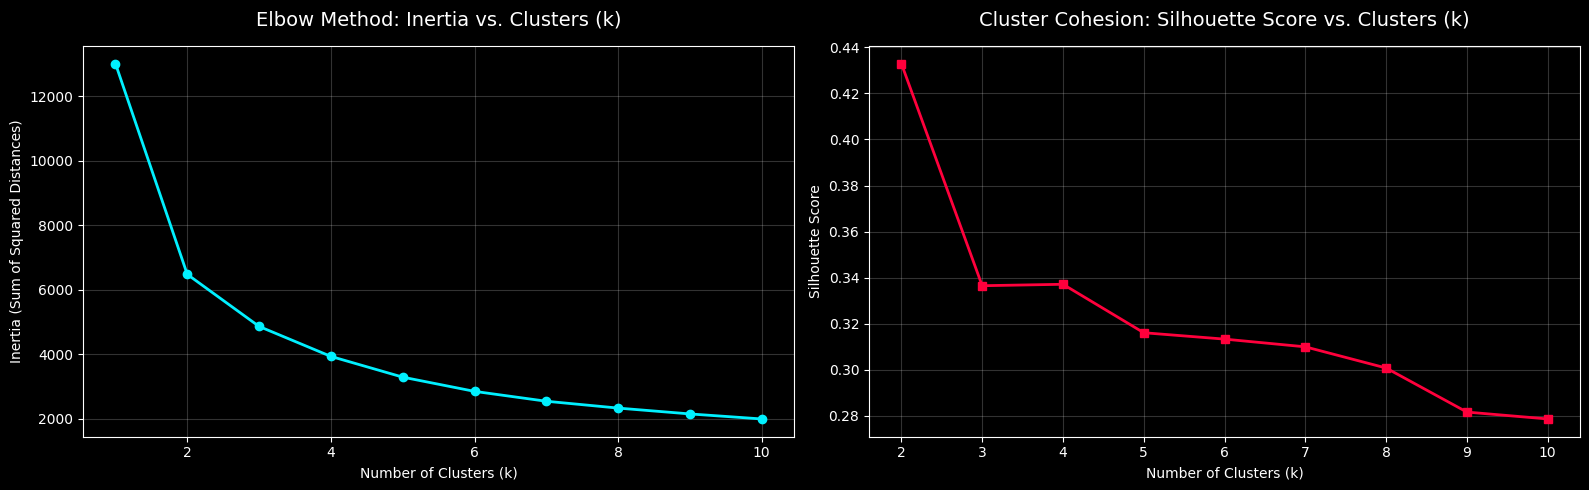

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Initialize arrays to track optimization metrics
inertia = []
silhouette_scores = []
k_range = range(2, 11)

print("Booting K-Means simulations. Calculating Euclidean distances...")

# Baseline inertia for k=1
kmeans_1 = KMeans(n_clusters=1, random_state=42, n_init=10)
inertia.append(kmeans_1.fit(df_rfm_scaled).inertia_)

# Simulate k=2 through k=10
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_rfm_scaled)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_rfm_scaled, kmeans.labels_))

print("Simulations complete. Rendering optimization charts...\n")

# Render the optimization charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: The Elbow Method
ax1.plot(range(1, 11), inertia, marker='o', color='#00F0FF', linewidth=2)
ax1.set_title('Elbow Method: Inertia vs. Clusters (k)', fontsize=14, pad=15)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Sum of Squared Distances)')
ax1.grid(True, alpha=0.2)

# Chart 2: The Silhouette Score
ax2.plot(k_range, silhouette_scores, marker='s', color='#FF003C', linewidth=2)
ax2.set_title('Cluster Cohesion: Silhouette Score vs. Clusters (k)', fontsize=14, pad=15)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()  

# 6. K-Means Execution & Persona Profiling
Deploying the optimal K-Means model ($k=4$) onto the normalized matrix. We then append the cluster assignments back to the original RFM dataset to interpret the core characteristics of each segment.

In [6]:
# Execute final clustering engine
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_rfm['Cluster'] = kmeans_final.fit_predict(df_rfm_scaled)

# Aggregate original metrics to define cluster personas
cluster_summary = df_rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)

# Flatten multi-level columns for cleaner presentation
cluster_summary.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Customer_Count']

# Sort by Monetary value to easily identify our "Whales" vs "Lost Customers"
cluster_summary = cluster_summary.sort_values(by='Avg_Monetary', ascending=False)

print("Cluster Profiling Complete.\n")
display(cluster_summary)

Cluster Profiling Complete.



,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Count
Cluster,,,,
1,12.1,13.7,8074.3,716
2,71.1,4.1,1802.8,1173
0,18.1,2.1,551.8,837
3,182.5,1.3,343.5,1612


# 7. Executive Business Personas & 3D Visualization
Translating the mathematical clusters into actionable marketing personas, and rendering a 3D interactive scatter plot to visualize the customer segmentation across the R, F, and M axes.

In [7]:
import plotly.express as px

# 1. Define the Business Personas
# (Note: Map these index numbers to the exact cluster IDs from your previous output)
persona_mapping = {
    cluster_summary.index[0]: 'The Champions',
    cluster_summary.index[1]: 'At-Risk Whales', 
    cluster_summary.index[2]: 'Active Buyers',
    cluster_summary.index[3]: 'Lost Customers'
}

# Apply personas to the master dataset
df_rfm['Persona'] = df_rfm['Cluster'].map(persona_mapping)

# 2. Render the 3D Interactive Engine
fig = px.scatter_3d(
    df_rfm, 
    x='Recency', 
    y='Frequency', 
    z='Monetary',
    color='Persona',
    title='3D RFM Customer Segmentation Matrix',
    color_discrete_sequence=['#00F0FF', '#FF003C', '#FCE205', '#64748B'],
    opacity=0.8,
    size_max=10
)

# Dark theme formatting to match the Cyberpunk Mainframe
fig.update_layout(
    template='plotly_dark',
    scene=dict(
        xaxis_title='Recency (Days)',
        yaxis_title='Frequency (Purchases)',
        zaxis_title='Monetary (Spend)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

# 8. Executive Summary & Strategic Implementation
The unsupervised learning engine successfully compressed over 397,000 raw transactional records into four distinct, mathematically proven behavioral personas. By transitioning from generic marketing to targeted cluster strategies, the business can immediately optimize its Return on Ad Spend (ROAS).

### Strategic Recommendations:
* **👑 The Champions (High Spend / High Frequency / Recent):** These are the whales. Do not offer them discounts—they don't need them. Instead, offer them exclusivity. Invite them to VIP loyalty programs, give them early access to new product lines, and assign dedicated account managers if applicable.
* **⚠️ At-Risk Whales (High Spend / High Frequency / Not Recent):** This is the highest-priority churn risk. These customers used to love the brand but have stopped buying. Deploy aggressive, high-value "Win-Back" campaigns (e.g., steep discounts, personalized outreach) immediately to reactivate their spending.
* **📈 Active Buyers (Medium Spend / Moderate Frequency / Recent):** The core pipeline. They are engaged but haven't reached their maximum lifetime value. Deploy targeted up-sell and cross-sell algorithms to migrate them into the Champions cluster.
* **👻 Lost Customers (Low Spend / Low Frequency / Not Recent):** The lowest ROI segment. Cease expensive targeted advertising for this group. Downgrade them to standard, automated email drip campaigns to minimize marketing overhead.